- **Gini** — стандарт в банках, рассчитывается как `2 * ROC-AUC - 1`. Он «растягивает» шкалу. Если ROC-AUC равен `0.95`, то Gini будет `0.90`. Разница между моделями станет в 2 раза заметнее.
- **F1-score** — покажет, какая модель лучше балансирует между пропуском мошенников и ложными отказами хорошим клиентам.

Результаты
Метрика оценки: ROC-AUC (чем выше тем лучше разделяет хороших и плохих заемщиков)
Бэггинг (Random Forest): ROC-AUC = 0.9614
Бэггинг (Random Forest): Gini = 0.9090
Бустинг (CatBoost): ROC-AUC = 0.9614
Бустинг (CatBoost): Gini = 0.9252
Стекинг (Stacking Ensemble): ROC-AUC = 0.9614
Стекинг (Stacking Ensemble): Gini = 0.9227


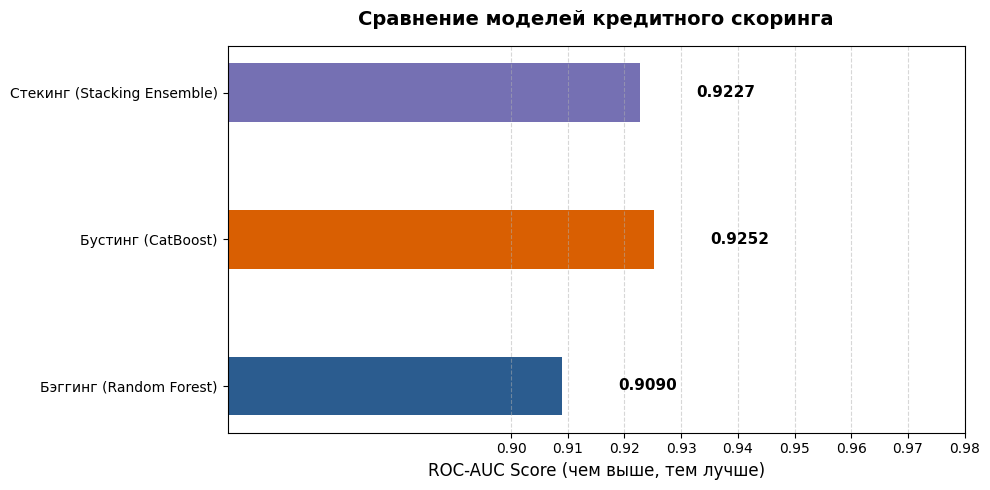

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# 1. Создание БИЗНЕС-КЕЙСА (Датасет кредитного скоринга)
# 10 000 клиентов, 15 признаков (доход, кредитная история, возраст и т.д.)
X, y = make_classification(
    n_samples=10000,
    n_features=15,
    n_informative=10,
    weights=[0.9, 0.1], # Дисбаланс, только 10% клиентов не возвращают кредит
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. ИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ
# Бэггинг
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Бустинг
cb_model = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, verbose=0, random_state=42)

# Стекинг - обьеденяет разные модели
base_estimators = [
    ('rf', rf_model),
    ('catboost', cb_model)
]

# Мета-модель учится исправлять ошибки базовых моделей на основе их ответов
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(),
    cv=5, # Кросс-валидация, чтобы избежать переобучения мета-модели
    n_jobs=-1
)

# Обучение и оценка
models = {
    "Бэггинг (Random Forest)": rf_model,
    "Бустинг (CatBoost)": cb_model,
    "Стекинг (Stacking Ensemble)": stacking_model
}

print("Результаты")
print("Метрика оценки: ROC-AUC (чем выше тем лучше разделяет хороших и плохих заемщиков)")

gini_dict = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    # нам нужны вероятности классов для расчета ROC-AUC
    preds = model.predict_proba(X_test)[:, 1] # [все элементы, ближе к классу 1]

    # ROC-AUC - вычисляет площадь под ROC кривой
    roc_auc = roc_auc_score(y_test, preds)
    print(f"{name}: ROC-AUC = {score:.4f}")

    # Коэффициент Джини
    gini = 2 * roc_auc - 1
    gini_dict[name] = gini
    print(f"{name}: Gini = {gini:.4f}")


# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(10, 5))
colors = ['#2b5c8f', '#d95f02', '#7570b3']
bars = plt.barh(list(gini_dict.keys()), list(gini_dict.values()), color=colors, height=0.4)

# Настраиваем границы графика (для скоринга актуально смотреть диапазон от 0.5 до 1.0)
plt.xlim(0.85, 0.95)
plt.xticks(np.arange(0.90, 0.99, 0.01))
plt.title('Сравнение моделей кредитного скоринга', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gini Score (чем выше, тем лучше)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
# Добавляем текстовые подписи с точными значениями прямо на график
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



## CatBoost: Выжимаем максимум без стекинга

Вместо сложного стекинга бизнес предпочитает качественно настроить один CatBoost. 

Вот ключевые гиперпараметры, которые сильнее всего влияют на точность:

In [ ]:
from catboost import CatBoostClassifier

# Конфигурация для максимальной точности
optimized_cb = CatBoostClassifier(
    iterations=1500,          # Увеличиваем число деревьев (но следим за переобучением)
    learning_rate=0.03,       # Уменьшаем шаг обучения (дает модели учиться "внимательнее")
    depth=6,                  # Оптимальная глубина (обычно от 4 до 10. Больше 10 — долго и переобучается)
    l2_leaf_reg=3,            # Регуляризация L2. Выше значение — меньше переобучение
    
    # Магия CatBoost для работы с категориальными признаками
    cat_features=cat_cols,    # Передаем список индексов или имен текстовых колонок
    one_hot_max_size=10,      # Категории с <10 уникальных значений кодируются через One-Hot автоматически
    
    # Защита от переобучения
    early_stopping_rounds=50, # Остановит обучение, если метрика на валидации не растет 50 итераций подряд
    eval_metric='AUC',        # Оптимизируем под конкретную бизнес-метрику
    
    random_seed=42,
    verbose=100               # Выводить логи каждые 100 итераций
)


**Секрет успеха:** Главное в CatBoost — правильно передать текстовые (категориальные) признаки в параметр `cat_features` без предварительного ручного кодирования. Алгоритм сам посчитает продвинутые статистики по ним на лету.